In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the preprocessed data



In [ ]:
df_preprocessed = pd.read_csv("/content/preprocessed_lung_cancer_data.csv")
print(f"Shape of the preprocessed DataFrame: {df_preprocessed.shape}")

Shape of the preprocessed DataFrame: (100211, 41)


## Split data




In [ ]:
from sklearn.model_selection import train_test_split
# Separate the target variable (y) and features (X)
y = df_preprocessed['survived']
X = df_preprocessed.drop(['id', 'survived', 'diagnosis_date', 'end_treatment_date'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80168, 37)
Shape of X_test: (20043, 37)
Shape of y_train: (80168,)
Shape of y_test: (20043,)


##Handle class imbalance



In [ ]:
print("Distribution of 'survived' in the training set:")
print(y_train.value_counts())
print("\nPercentage distribution of 'survived' in the training set:")
print(y_train.value_counts(normalize=True) * 100)

Distribution of 'survived' in the training set:
survived
0    62479
1    17689
Name: count, dtype: int64

Percentage distribution of 'survived' in the training set:
survived
0    77.935086
1    22.064914
Name: proportion, dtype: float64


## Hyperparameter Tuning

Tune the hyperparameters of the Decision Tree Classifier using GridSearchCV.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best recall score from GridSearchCV: {best_score:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best recall score from GridSearchCV: 0.5146


## Train the Decision Tree Classifier with Tuned Hyperparameters

Train the Decision Tree Classifier using the best hyperparameters found during tuning.

In [ ]:
# Instantiate a DecisionTreeClassifier with the best parameters and balanced class weight
dt_tuned_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, **best_params)

# Train the model
dt_tuned_model.fit(X_train, y_train)

print("Tuned Decision Tree Classifier model trained successfully.")

Tuned Decision Tree Classifier model trained successfully.


## Evaluation of Tuned Model

Evaluate the performance of the tuned Decision Tree Classifier on the test set.

Accuracy (Tuned Model): 0.5352
Precision (Tuned Model): 0.2160
Recall (Tuned Model): 0.4267
F1 Score (Tuned Model): 0.2868


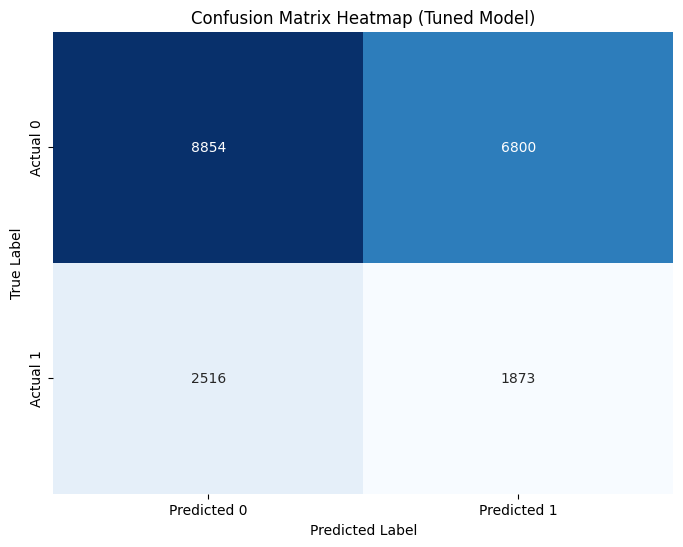

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set using the tuned model
y_pred_tuned = dt_tuned_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='binary')
recall_tuned = recall_score(y_test, y_pred_tuned, average='binary')
f1_tuned = f1_score(y_test, y_pred_tuned, average='binary')

# Print the evaluation metrics for the tuned model
print(f"Accuracy (Tuned Model): {accuracy_tuned:.4f}")
print(f"Precision (Tuned Model): {precision_tuned:.4f}")
print(f"Recall (Tuned Model): {recall_tuned:.4f}")
print(f"F1 Score (Tuned Model): {f1_tuned:.4f}")

# Calculate the confusion matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Create a heatmap of the confusion matrix for the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Tuned Model)')
plt.show()